In [13]:
from google.colab import drive
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt 

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

print("Bismillah\nAllah hy Akbar")

Bismillah
Allah hy Akbar


In [14]:
drive.mount('/content/drive')

df = pd.read_csv('/content/drive/MyDrive/AI/beijing-pm2.5-data.csv')

print(df)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
          No  year  month  day  hour  pm2.5  DEWP  TEMP    PRES cbwd     Iws  \
0          1  2010      1    1     0    NaN   -21 -11.0  1021.0   NW    1.79   
1          2  2010      1    1     1    NaN   -21 -12.0  1020.0   NW    4.92   
2          3  2010      1    1     2    NaN   -21 -11.0  1019.0   NW    6.71   
3          4  2010      1    1     3    NaN   -21 -14.0  1019.0   NW    9.84   
4          5  2010      1    1     4    NaN   -20 -12.0  1018.0   NW   12.97   
...      ...   ...    ...  ...   ...    ...   ...   ...     ...  ...     ...   
43819  43820  2014     12   31    19    8.0   -23  -2.0  1034.0   NW  231.97   
43820  43821  2014     12   31    20   10.0   -22  -3.0  1034.0   NW  237.78   
43821  43822  2014     12   31    21   10.0   -22  -3.0  1034.0   NW  242.70   
43822  43823  2014     12   31    22    8.0   -22  -4.0  1034.0   NW  2

In [15]:
df.dropna(axis=0, inplace=True)
df["date"] = pd.to_datetime(df[["year", "month", "day", "hour"]])
df.set_index("date", inplace=True)

df.drop(["year", "month", "day", "hour", "No", "cbwd"], axis=1, inplace=True)
print(df)

                     pm2.5  DEWP  TEMP    PRES     Iws  Is  Ir
date                                                          
2010-01-02 00:00:00  129.0   -16  -4.0  1020.0    1.79   0   0
2010-01-02 01:00:00  148.0   -15  -4.0  1020.0    2.68   0   0
2010-01-02 02:00:00  159.0   -11  -5.0  1021.0    3.57   0   0
2010-01-02 03:00:00  181.0    -7  -5.0  1022.0    5.36   1   0
2010-01-02 04:00:00  138.0    -7  -5.0  1022.0    6.25   2   0
...                    ...   ...   ...     ...     ...  ..  ..
2014-12-31 19:00:00    8.0   -23  -2.0  1034.0  231.97   0   0
2014-12-31 20:00:00   10.0   -22  -3.0  1034.0  237.78   0   0
2014-12-31 21:00:00   10.0   -22  -3.0  1034.0  242.70   0   0
2014-12-31 22:00:00    8.0   -22  -4.0  1034.0  246.72   0   0
2014-12-31 23:00:00   12.0   -21  -3.0  1034.0  249.85   0   0

[41757 rows x 7 columns]


In [16]:
def prepareDataForLSTM(data, windowSize):
    X, y = [], []
    
    for i in range(0, len(data)-windowSize):
        
        X.append(data[i:i+windowSize, :])
        y.append(data[i+windowSize, 0])
        
    return np.array(X), np.array(y)


In [17]:
scaler = MinMaxScaler(feature_range=(0, 1))

data = scaler.fit_transform(df)

print(data)

[[0.12977867 0.35294118 0.24590164 ... 0.00237151 0.         0.        ]
 [0.14889336 0.36764706 0.24590164 ... 0.00394662 0.         0.        ]
 [0.15995976 0.42647059 0.2295082  ... 0.00552173 0.         0.        ]
 ...
 [0.01006036 0.26470588 0.26229508 ... 0.42873071 0.         0.        ]
 [0.00804829 0.26470588 0.24590164 ... 0.43584525 0.         0.        ]
 [0.01207243 0.27941176 0.26229508 ... 0.44138468 0.         0.        ]]


In [18]:
X, y = prepareDataForLSTM(data, 24)

print(X)
print(f'\n\n{X.shape}')


# print(f'y: {y}\n\nX: {X}\n')

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(X_train.shape)

[[[0.12977867 0.35294118 0.24590164 ... 0.00237151 0.         0.        ]
  [0.14889336 0.36764706 0.24590164 ... 0.00394662 0.         0.        ]
  [0.15995976 0.42647059 0.2295082  ... 0.00552173 0.         0.        ]
  ...
  [0.16498994 0.48529412 0.2295082  ... 0.08622398 0.03703704 0.        ]
  [0.15694165 0.47058824 0.21311475 ... 0.09176341 0.07407407 0.        ]
  [0.12676056 0.47058824 0.21311475 ... 0.09730285 0.11111111 0.        ]]

 [[0.14889336 0.36764706 0.24590164 ... 0.00394662 0.         0.        ]
  [0.15995976 0.42647059 0.2295082  ... 0.00552173 0.         0.        ]
  [0.18209256 0.48529412 0.2295082  ... 0.00868965 0.03703704 0.        ]
  ...
  [0.15694165 0.47058824 0.21311475 ... 0.09176341 0.07407407 0.        ]
  [0.12676056 0.47058824 0.21311475 ... 0.09730285 0.11111111 0.        ]
  [0.09054326 0.48529412 0.21311475 ... 0.10284228 0.14814815 0.        ]]

 [[0.15995976 0.42647059 0.2295082  ... 0.00552173 0.         0.        ]
  [0.18209256 0.485294

In [19]:
model = Sequential()

model.add(
    LSTM(
        units=50, input_shape=(X_train.shape[1], X_train.shape[2]), return_sequences=False
    )
)

model.add(Dropout(0.2))

model.add(Dense(units=1))

model.compile(optimizer='adam', loss='mean_squared_error' ,metrics=['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [20]:
history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=72,
    validation_data=(X_test, y_test),
    verbose=1,
    shuffle=False,
)

Epoch 1/20
464/464 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - accuracy: 5.9905e-05 - loss: 0.0032 - val_accuracy: 0.0000e+00 - val_loss: 0.0011
Epoch 2/20
464/464 ━━━━━━━━━━━━━━━━━━━━ 9s 20ms/step - accuracy: 5.9905e-05 - loss: 0.0011 - val_accuracy: 0.0000e+00 - val_loss: 8.0943e-04
Epoch 3/20
464/464 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - accuracy: 5.9905e-05 - loss: 8.6931e-04 - val_accuracy: 0.0000e+00 - val_loss: 7.4288e-04
Epoch 4/20
464/464 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step - accuracy: 5.9905e-05 - loss: 7.6616e-04 - val_accuracy: 0.0000e+00 - val_loss: 6.5317e-04
Epoch 5/20
464/464 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 5.9905e-05 - loss: 7.1242e-04 - val_accuracy: 0.0000e+00 - val_loss: 6.3147e-04
Epoch 6/20
464/464 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - accuracy: 5.9905e-05 - loss: 6.7130e-04 - val_accuracy: 0.0000e+00 - val_loss: 6.1073e-04
Epoch 7/20
464/464 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - accuracy: 5.9905e-05 - loss: 6.5685e-04 - val_accuracy: 0.0000e+00 - val_loss: 6.2924e

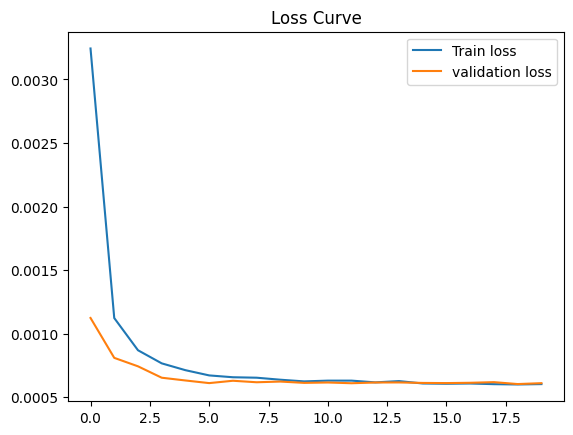

In [21]:
plt.plot(history.history['loss'], label='Train loss')
plt.plot(history.history['val_loss'], label='validation loss')
plt.legend()
plt.title('Loss Curve')
plt.show()


In [22]:
from sklearn.metrics import root_mean_squared_error

predictions = model.predict(X_test)

dummy_array = np.zeros((len(predictions), 7))
dummy_array[:, 0] = predictions.flatten()
inverse_dummy = scaler.inverse_transform(dummy_array)
final_predictions = inverse_dummy[:, 0]

dummy_array = np.zeros((len(y_test), 7))
dummy_array[:, 0] = y_test.flatten()
inverse_dummy = scaler.inverse_transform(dummy_array)
y_test = inverse_dummy[:, 0]



print(f"RMSE: {root_mean_squared_error(y_test, final_predictions)}")



261/261 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
RMSE: 24.55568369864797
